# FinTrust Digital Bank — Week 2 Python Exploratory Data Analysis

**Track:** Data Analytics
**Author:** Yawa Jacqueline GBEDEVI
**Purpose:** Explore the FinTrust customer and transaction datasets to surface patterns
across customer segments, transaction types, amounts, channels, status, international
transactions, customer behaviour and risk-review flagging.

**Note:** `Risk_Review_Flag` is a synthetic educational label only. It is not a real
fraud determination and is not used here to make any real banking decision.


## 1. Setup and data loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)

# Adjust the paths below to wherever your files are stored
customer = pd.read_csv("FinTrust_Customer_Data.csv",delimiter=";")
transactions = pd.read_csv("FinTrust_Transaction_Data.csv",delimiter=";")

print(customer.shape, transactions.shape)


(1500, 20) (12000, 11)


## 2. Joining customer and transaction data

Merging on `Customer_ID` so customer attributes (segment, tenure, etc.) can be analysed against transaction behaviour.

In [6]:
df = transactions.merge(customer, on='Customer_ID', how='left')
print(df.shape)
df.head()


(12000, 30)


,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,...,Preferred_Channel,Account_Status,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,FT-T010114,FT-C00901,17 03 2026 20:29,Airtime/Data,"100,17",POS,iOS,Benin City,No,Failed,...,Web,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FT-T000647,FT-C01157,5 01 2026 20:17,Airtime/Data,"100,2",USSD,Web Browser,Lagos,No,Successful,...,Web,Dormant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FT-T003065,FT-C01173,23 01 2026 23:33,Airtime/Data,"101,04",USSD,POS Terminal,Abuja,No,Successful,...,Mobile App,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FT-T004837,FT-C01208,6 02 2026 06:33,Airtime/Data,"101,26",POS,Android,Abuja,No,Successful,...,USSD,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,FT-T008187,FT-C00204,3 03 2026 09:36,Airtime/Data,"101,36",Mobile App,Android,Kaduna,No,Successful,...,Mobile App,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Visualization 1 — Transaction volume by type

C:\Users\Yvette\AppData\Local\Temp\ipykernel_24588\1470897237.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y='Transaction_Type', order=order, palette='Blues_r')


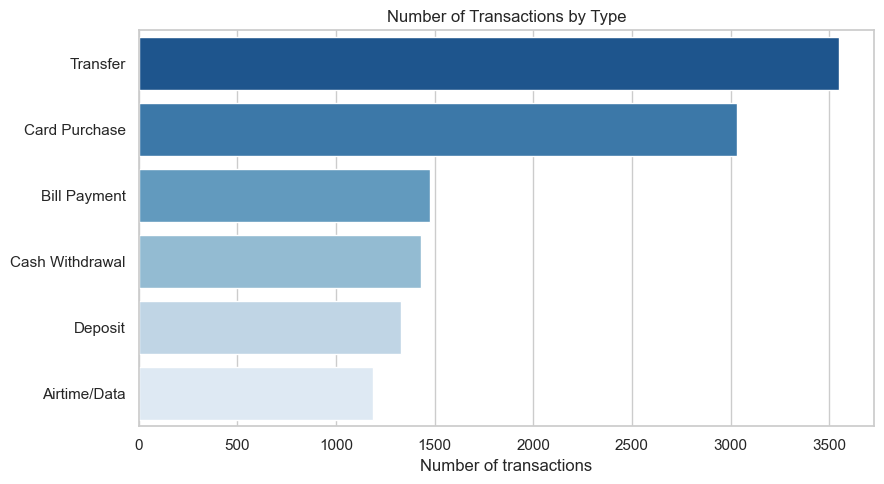

In [7]:
order = df['Transaction_Type'].value_counts().index
ax = sns.countplot(data=df, y='Transaction_Type', order=order, palette='Blues_r')
ax.set_title('Number of Transactions by Type')
ax.set_xlabel('Number of transactions')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


**What it shows:** Transfers and Card Purchases are by far the most frequent transaction types, together making up more than half of all activity.

**Why it's important:** Volume drives operational load. The transaction types customers use most are the ones where reliability issues will affect the largest number of people.

**Business insight:** FinTrust should prioritise monitoring and improving the Transfer and Card Purchase flows first, since any friction there impacts the majority of daily activity.

## 4. Visualization 2 — Distribution of transaction amounts

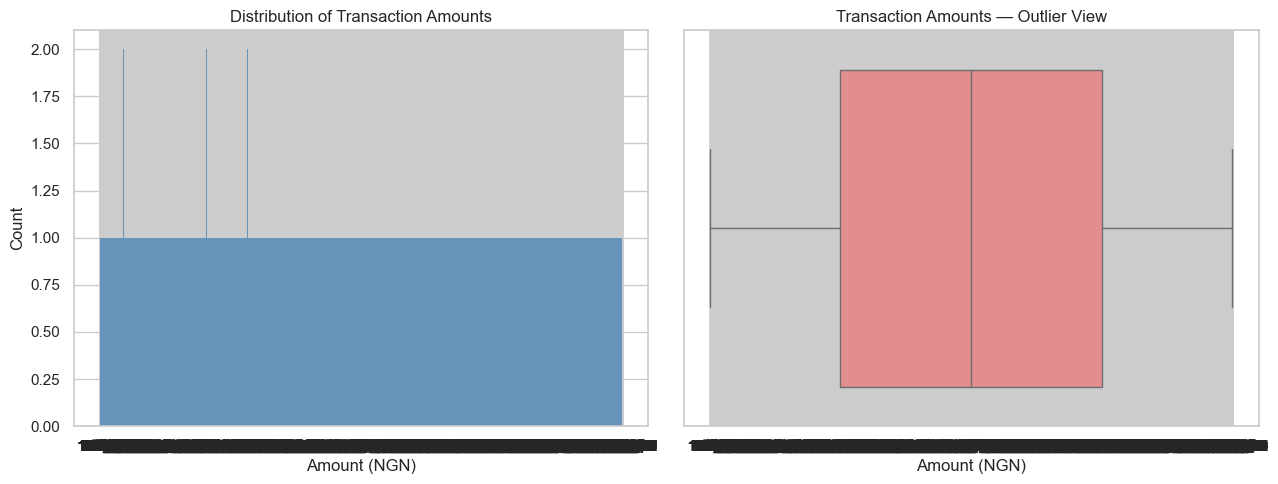

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df['Amount_NGN'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Transaction Amounts')
axes[0].set_xlabel('Amount (NGN)')

sns.boxplot(x=df['Amount_NGN'], ax=axes[1], color='lightcoral')
axes[1].set_title('Transaction Amounts — Outlier View')
axes[1].set_xlabel('Amount (NGN)')

plt.tight_layout()
plt.show()


**What it shows:** The distribution is heavily right-skewed: most transactions are small, but a long tail of high-value transactions stretches out to over 690,000 NGN. The boxplot highlights the same high-value transactions as outliers (the ones above roughly 118,000 NGN identified in the Data Quality Report).

**Why it's important:** A skewed distribution means simple averages can be misleading; a few large transactions can pull the mean up even though most customers transact for much smaller amounts.

**Business insight:** FinTrust's typical customer transaction is modest, but the small number of high-value transactions deserves separate attention (they are the ones most often linked to risk review, as shown further down).

## .5 Visualization 3 — Total transaction value by channel

In [10]:
channel_value = df.groupby('Channel')['Amount_NGN'].sum().sort_values(ascending=False)
ax = channel_value.plot(kind='bar', color='seagreen')
ax.set_title('Total Transaction Value by Channel')
ax.set_ylabel('Total value (NGN)')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


TypeError: no numeric data to plot

**What it shows:** The Mobile App channel generates by far the highest total transaction value, well ahead of POS, Web, ATM and USSD.

**Why it's important:** This confirms where the business value is concentrated. It's also the channel most exposed if something goes wrong (an outage or a bug on mobile app affects the most value and the most customers).

**Business insight:** Mobile App should be treated as FinTrust's primary channel for investment in reliability, security and new features, since it carries most of the transactional value.

## 6. Visualization 4 — Transaction status and failure rate by channel

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

status_order = df['Transaction_Status'].value_counts().index
sns.countplot(data=df, x='Transaction_Status', order=status_order, ax=axes[0], palette='Set2')
axes[0].set_title('Overall Transaction Status')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of transactions')

fail_rate = (df.assign(is_failed=df['Transaction_Status'] == 'Failed')
               .groupby('Channel')['is_failed'].mean().mul(100).sort_values(ascending=False))
fail_rate.plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Failure Rate by Channel (%)')
axes[1].set_ylabel('% Failed')
axes[1].set_xlabel('')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


**What it shows:** Overall, 90.5% of transactions succeed. But broken down by channel, Mobile App has the highest failure rate (about 5.8%), even though it's also the most-used channel.

**Why it's important:** A high failure rate on the most-used channel affects more customers in absolute terms than the same rate on a smaller channel.

**Business insight:** Mobile App reliability is the single highest-leverage improvement area for FinTrust: it's both the most-used and the least reliable channel, which compounds customer impact.

## 7. Visualization 5 — Risk review rate: international vs domestic transactions

In [ ]:
risk_intl = (df.assign(flagged=df['Risk_Review_Flag'] == 'Yes')
               .groupby('International_Transaction')['flagged'].mean().mul(100))
ax = risk_intl.plot(kind='bar', color=['#4C72B0', '#DD8452'])
ax.set_title('Risk Review Rate: International vs Domestic Transactions')
ax.set_ylabel('% Flagged for Review')
ax.set_xlabel('International Transaction')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**What it shows:** International transactions are flagged for risk review about 36.9% of the time, versus 18.9% for domestic transactions, nearly double the rate.

**Why it's important:** This shows the flagging logic responds to a meaningful, understandable factor, rather than being random. It also tells us international transactions are a distinct category worth watching operationally.

**Business insight:** Even though `Risk_Review_Flag` is synthetic here, the pattern itself is realistic: cross-border transactions typically carry higher review needs. FinTrust's future real risk model should treat international transactions as a separate segment for review.

## 8. Visualization 6 — Average transaction value by customer segment

In [ ]:
seg_value = df.groupby('Customer_Segment')['Amount_NGN'].mean().sort_values(ascending=False)
ax = seg_value.plot(kind='bar', color='mediumpurple')
ax.set_title('Average Transaction Value by Customer Segment')
ax.set_ylabel('Average amount (NGN)')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**What it shows:** SME customers have the highest average transaction value (about 49,100 NGN), narrowly ahead of Student, Everyday and Premium, which are all fairly close to each other.

**Why it's important:** It's a reminder not to assume the "Premium" label automatically means the highest transaction values; here it's actually the lowest of the four segments on this metric.

**Business insight:** FinTrust may want to re-examine whether its Premium segment's products and benefits truly match its transaction behaviour, and whether SME customers, who post the highest average values, are receiving business-appropriate account features.

## 9. Summary of key findings

| # | Finding | Evidence | Business meaning |
|---|---|---|---|
| 1 | Transfers and Card Purchases dominate transaction volume | 29.6% + 25.3% of all transactions | These two flows should be the top reliability priority |
| 2 | Transaction amounts are heavily right-skewed | Long tail above ~118,000 NGN | Averages alone can mislead; high-value transactions need separate tracking |
| 3 | Mobile App carries the most value but also the highest failure rate | 240M NGN total value, 5.8% failure rate | Highest-leverage channel for reliability investment |
| 4 | International transactions are flagged for review far more often | 36.9% vs 18.9% domestic | Flagging logic follows a sensible pattern tied to transaction risk factors |
| 5 | SME customers have the highest average transaction value, not Premium | 49,116 NGN vs 45,638 NGN for Premium | Worth reassessing whether Premium and SME product offerings match actual usage |

**Limitations:** this analysis is based on synthetic data created for educational purposes. `Risk_Review_Flag` does not reflect a real fraud or banking risk decision, and findings should not be used for real financial or business decisions.
